In [1]:
import sqlite3

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

from mpl_toolkits.mplot3d import Axes3D

In [2]:
conn = sqlite3.connect("data.db")
query = "SELECT * FROM measurements"

df = pl.read_database(query=query, connection=conn)
df

trace_name,alg_name,cache_invalidation_method_compress,cache_invalidation_method_decompress,page_number,compressed_size,uncompressed_size,compression_time,decompression_time
str,str,i64,i64,i64,i64,i64,i64,i64
"""build-llvm""","""lz4""",0,0,1,4107,4096,20285,6267
"""build-llvm""","""lz4""",0,0,2,4108,4096,11144,3632
"""build-llvm""","""lz4""",0,0,3,4108,4096,11096,3764
"""build-llvm""","""lz4""",0,0,4,4108,4096,11165,3739
"""build-llvm""","""lz4""",0,0,5,4110,4096,11302,3808
…,…,…,…,…,…,…,…,…
"""ollama""","""zstd""",1,1,2938,657,4096,20654,10287
"""ollama""","""zstd""",1,1,2939,4106,4096,17311,1711
"""ollama""","""zstd""",1,1,2940,4106,4096,16880,1816


<Axes: xlabel='page_number', ylabel='smooth_comptime'>

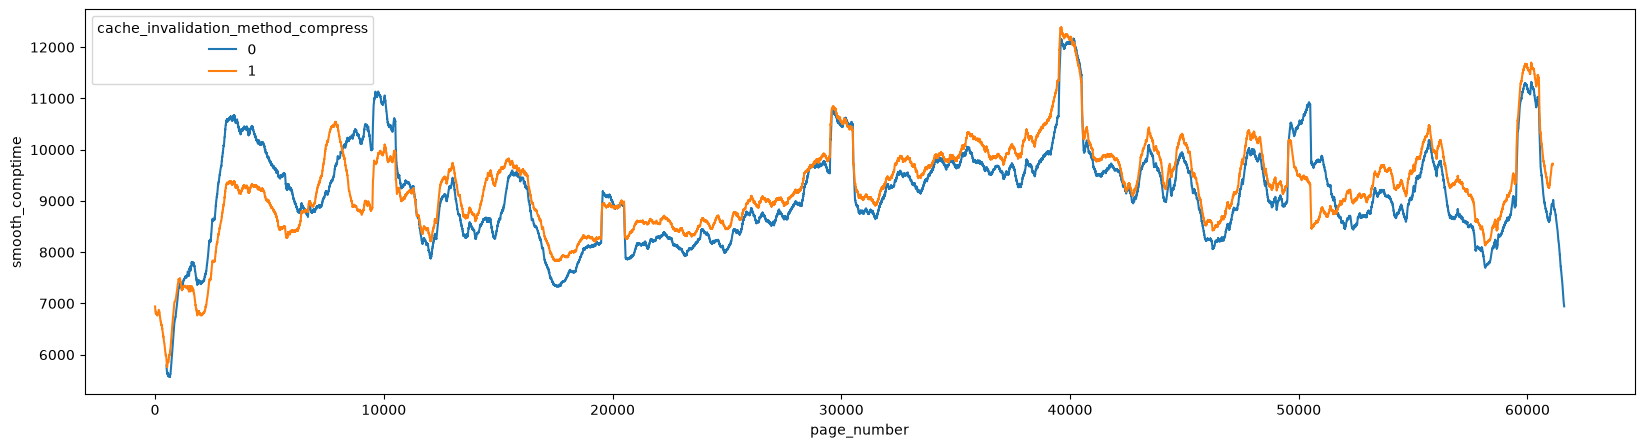

In [3]:
df1 = df.filter(
    pl.col("trace_name") == "build-llvm",
    pl.col("alg_name") == "lz4",
    pl.col("cache_invalidation_method_decompress") == 0,
).with_columns(
    pl.col("compression_time").rolling_mean(window_size=1000, center=True).alias("smooth_comptime")
)

plt.figure(figsize=(20,5))
sns.lineplot(
    df1,
    x="page_number",
    y="smooth_comptime",
    hue="cache_invalidation_method_compress"
)

<Axes: xlabel='page_number', ylabel='smooth_comptime'>

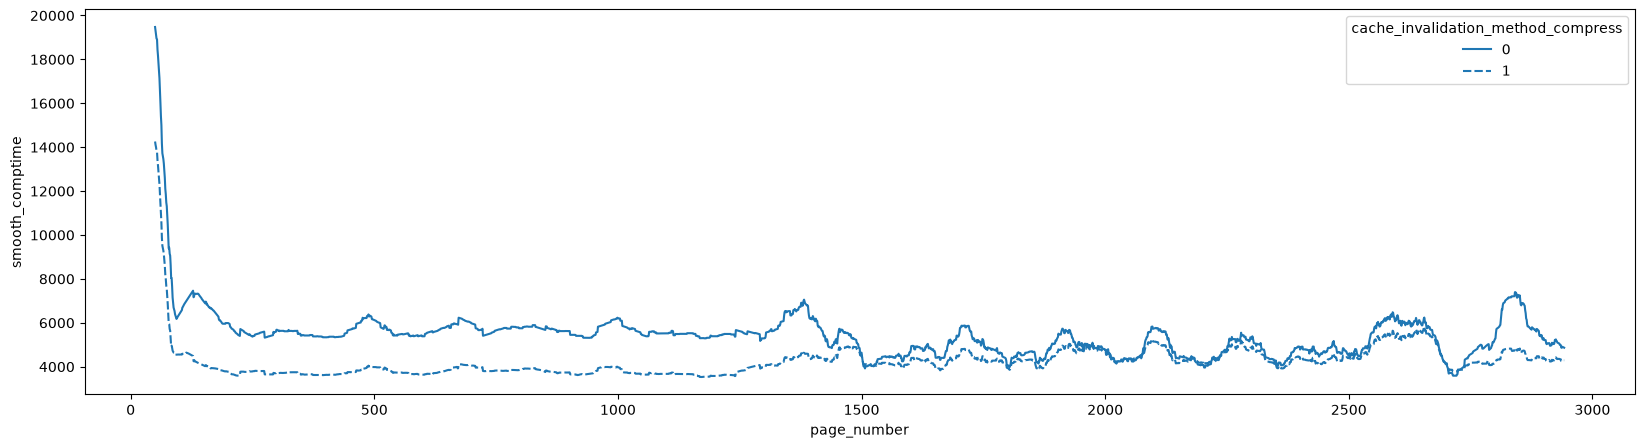

In [12]:
df1 = df.filter(
    pl.col("trace_name") == "ollama",
    pl.col("alg_name") == "lz4",
    pl.col("cache_invalidation_method_decompress") == 0,
).with_columns(
    pl.col("compression_time")
    .rolling_mean(window_size=50)
    .over("cache_invalidation_method_compress")
    .alias("smooth_comptime")
)

plt.figure(figsize=(20,5))
sns.lineplot(
    df1,
    x="page_number",
    y="smooth_comptime",
    style="cache_invalidation_method_compress"
)

In [9]:
df1

trace_name,alg_name,cache_invalidation_method_compress,cache_invalidation_method_decompress,page_number,compressed_size,uncompressed_size,compression_time,decompression_time,smooth_comptime
str,str,i64,i64,i64,i64,i64,i64,i64,f64
"""ollama""","""lz4""",0,0,1,34,4096,14182,8589,null
"""ollama""","""lz4""",0,0,2,503,4096,12158,7172,null
"""ollama""","""lz4""",0,0,3,740,4096,16101,8394,null
"""ollama""","""lz4""",0,0,4,103,4096,6773,4510,null
"""ollama""","""lz4""",0,0,5,1649,4096,29342,12393,null
…,…,…,…,…,…,…,…,…,…
"""ollama""","""lz4""",1,0,2938,1064,4096,5852,2834,null
"""ollama""","""lz4""",1,0,2939,4114,4096,3881,1078,null
"""ollama""","""lz4""",1,0,2940,4114,4096,3871,1078,null


In [ ]:
df.filter(
    pl.col("trace_name") == "ollama",
    pl.col
)

trace_name,alg_name,cache_invalidation_method_compress,cache_invalidation_method_decompress,page_number,compressed_size,uncompressed_size,compression_time,decompression_time
str,str,i64,i64,i64,i64,i64,i64,i64
"""ollama""","""lz4""",0,0,1,34,4096,14182,8589
"""ollama""","""lz4""",0,0,2,503,4096,12158,7172
"""ollama""","""lz4""",0,0,3,740,4096,16101,8394
"""ollama""","""lz4""",0,0,4,103,4096,6773,4510
"""ollama""","""lz4""",0,0,5,1649,4096,29342,12393
…,…,…,…,…,…,…,…,…
"""ollama""","""zstd""",1,1,2938,657,4096,20654,10287
"""ollama""","""zstd""",1,1,2939,4106,4096,17311,1711
"""ollama""","""zstd""",1,1,2940,4106,4096,16880,1816
